# 03. VADER Sentiment Analysis

Applies VADER sentiment analysis to USHMM reviews using a two-channel model
that separates affective tone from evaluative sentiment.

**Input:** `../Data/Processed/ushmm_tripadvisor_eng_full.csv`  
**Output:** `../Data/Processed/ushmm_tripadvisor_eng_vader.csv`

> **Note on input:** This notebook reads from `ushmm_tripadvisor_eng_full.csv`,
> produced by `01b_data_exploration_full.ipynb` from the raw Apify Excel file.
> This replaces the older `ushmm_tripadvisor_eng.csv` (from `01_data_exploration.ipynb`),
> which used probabilistic language detection and retained only 5 columns.
> The full CSV adds `published_date`, `platform`, `reviewer_total_contributions`,
> and other metadata columns, enabling richer downstream analysis.
> English review count differs by 2 rows (10,114 vs 10,116) due to the
> switch from `langdetect` to Apify's native `lang` field — results are unaffected.

## The Memorial Paradox Problem
Standard VADER scores tragic language (e.g. 'horrific', 'genocide') as negative,
even in glowing 5-star reviews. This notebook addresses that with a two-channel model:

- `emo_vader` — raw VADER score; captures **affective/emotional tone**
- `eval_vader` — tuned VADER score; captures **evaluative sentiment** about the museum

Tuning involves two steps:
1. Neutralizing atrocity-domain words in the VADER lexicon
2. Rating-aware clamping: negative eval scores for 4/5-star reviews set to 0

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, norm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [ ]:
df = pd.read_csv("../Data/Processed/ushmm_tripadvisor_eng_full.csv")
print(df.shape)
df.head()

(10116, 5)


,likes,rating,review_text,group_type,reviewer_location
0,0,5,We spent four hours and could have spent eight...,COUPLES,"Bradley, Illinois"
1,1,5,We are Germans visiting this museum. Most of t...,FAMILY,"Heidelberg, Germany"
2,0,5,This museum is incredible and incredibly impor...,FAMILY,"Otsego, Minnesota"
3,0,5,I visited the Holocaust Museum in August 2024....,SOLO,"New York City, New York"
4,0,4,I learned so much. The place has a very sad vi...,FRIENDS,"Lewiston, New York"


## 1. Baseline VADER Scores

Apply standard VADER to all reviews. This produces `emo_vader` —
the raw emotional tone channel.

In [ ]:
an = SentimentIntensityAnalyzer()
df["emo_vader"] = df["review_text"].astype(str).apply(
    lambda s: an.polarity_scores(s)["compound"]
)

print("Baseline VADER (emo_vader):")
print(df["emo_vader"].describe().round(3))

Baseline VADER (emo_vader):
count    10116.000
mean         0.302
std          0.596
min         -0.996
25%         -0.151
50%          0.502
75%          0.821
max          0.999
Name: emo_vader, dtype: float64


In [ ]:
print("Mean emo_vader by star rating:")
print(df.groupby("rating")["emo_vader"].mean().round(3))

print("\nMean emo_vader by group type:")
print(df.groupby("group_type")["emo_vader"].mean().round(3))

print("\nCorrelation (emo_vader vs rating):",
      df[["emo_vader", "rating"]].corr().iloc[0, 1].round(3))

Mean emo_vader by star rating:
rating
1   -0.076
2    0.050
3    0.163
4    0.300
5    0.317
Name: emo_vader, dtype: float64

Mean emo_vader by group type:
group_type
BUSINESS    0.266
COUPLES     0.268
FAMILY      0.327
FRIENDS     0.324
NONE        0.299
SOLO        0.300
Name: emo_vader, dtype: float64

Correlation (emo_vader vs rating): 0.08


In [ ]:
# Illustrate the memorial paradox: high-star reviews with negative VADER
def show_examples(mask, df, k=3, title="Examples"):
    print(f"\n{title}")
    subset = df.loc[mask, ["review_text", "rating", "emo_vader"]].dropna().head(k)
    for _, row in subset.iterrows():
        print(f"  [★{int(row['rating'])}, emo={row['emo_vader']:.2f}] "
              f"{str(row['review_text'])[:250]}...")

show_examples(df["emo_vader"] > 0.7, df, title="Highly positive tone (emo > 0.7)")
show_examples(df["emo_vader"] < -0.4, df, title="Negative tone (emo < -0.4) — memorial paradox cases")


Highly positive tone (emo > 0.7)
  [★5, emo=0.71] We are Germans visiting this museum. Most of the facts you know from school - so not so much new information. But the presentation moved me to tears twice. When an elderly man explained the Warsaw milk cans, and at the end when some videos were shown...
  [★5, emo=0.81] This museum is truly incredible. The way they have it set up to take you on a journey through World War II and the Holocaust is haunting, but tells a very important story. This is somewhere important for everyone to go and truly take in everything th...
  [★5, emo=0.89] Like all Holocaust Museums, this one is very sad, but a learning experience. The museum was designed as a walkthrough which I found much easier, although the beginning exhibits are very packed. One of my favorite exhibits was were there were pictures...

Negative tone (emo < -0.4) — memorial paradox cases
  [★5, emo=-0.67] I visited the Holocaust Museum in August 2024.  I visited here several times many 

## 2. Sentiment Distribution Plot

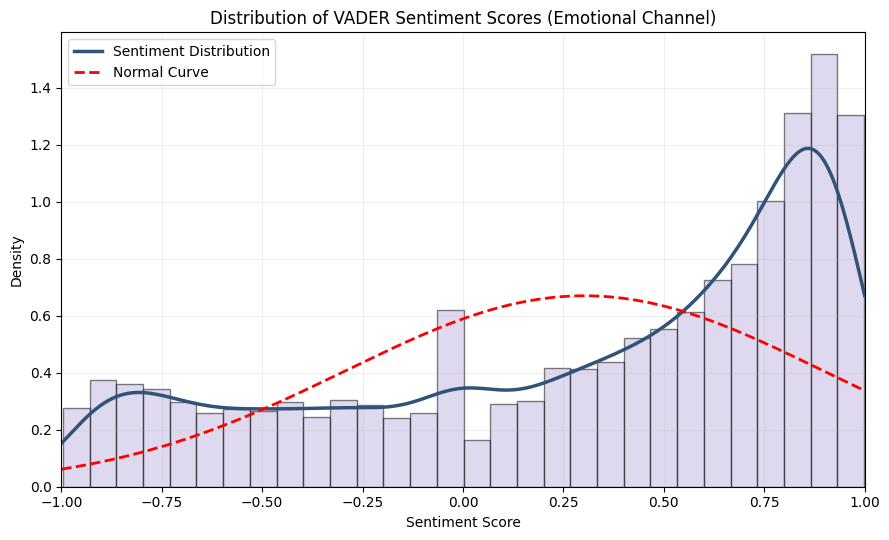

In [ ]:
sentiment = df["emo_vader"].dropna().to_numpy()
xs = np.linspace(-1, 1, 400)
kde = gaussian_kde(sentiment)
mu, sigma = sentiment.mean(), sentiment.std(ddof=1)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(sentiment, bins=30, density=True, alpha=0.5,
        color="#c1b4e1", edgecolor="black")
ax.plot(xs, kde(xs), linewidth=2.5, label="Sentiment Distribution", color="#305479")
ax.plot(xs, norm.pdf(xs, loc=mu, scale=sigma), "r--",
        linewidth=2, label="Normal Curve")
ax.set_title("Distribution of VADER Sentiment Scores (Emotional Channel)")
ax.set_xlabel("Sentiment Score")
ax.set_ylabel("Density")
ax.set_xlim(-1, 1)
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.savefig("../Outputs/Figures/vader_sentiment_distribution.png", dpi=150)
plt.show()

## 3. Evaluative Channel — Lexicon Tuning

Neutralize atrocity-domain words that carry negative valence in standard VADER
but function descriptively (not evaluatively) in Holocaust museum reviews.
This produces `eval_vader` — the evaluative sentiment channel.

In [ ]:
an_tuned = SentimentIntensityAnalyzer()

# Words that describe Holocaust content, not museum quality
neutralize = [
    "sad", "tragic", "horrific", "horror", "terrible", "disturbing", "shocking",
    "heartbreaking", "upsetting", "grief", "sorrow", "genocide", "atrocity",
    "gas", "camp"
]
for w in neutralize:
    an_tuned.lexicon[w] = 0.0

df["eval_vader"] = df["review_text"].astype(str).apply(
    lambda s: an_tuned.polarity_scores(s)["compound"]
)

# Rating-aware clamping: high-star reviews should not score negative evaluatively
hi = df["rating"] >= 4
df.loc[hi & (df["eval_vader"] < 0), "eval_vader"] = 0.0

print("Evaluative VADER (eval_vader):")
print(df["eval_vader"].describe().round(3))

Evaluative VADER (eval_vader):
count    10116.000
mean         0.476
std          0.395
min         -0.987
25%          0.000
50%          0.572
75%          0.836
max          0.999
Name: eval_vader, dtype: float64


In [ ]:
print("Comparison of channels by star rating:")
print(df.groupby("rating")[["emo_vader", "eval_vader"]].mean().round(3))

print("\nCorrelations with star rating:")
print("  emo_vader: ", df[["emo_vader", "rating"]].corr().iloc[0, 1].round(3))
print("  eval_vader:", df[["eval_vader", "rating"]].corr().iloc[0, 1].round(3))

Comparison of channels by star rating:
        emo_vader  eval_vader
rating                       
1          -0.076      -0.030
2           0.050       0.077
3           0.163       0.199
4           0.300       0.485
5           0.317       0.499

Correlations with star rating:
  emo_vader:  0.08
  eval_vader: 0.192


## 4. Two-Channel Quadrant Classification

Classify each review into one of four quadrants based on emotional
tone and evaluative sentiment:

| | Eval+ | Eval- |
|---|---|---|
| **Emo+** | Emo+ / Eval+ | Emo+ / Eval- |
| **Emo-** | **Emo- / Eval+** | Emo- / Eval- |

The **Emo- / Eval+** quadrant is the empirical signature of the Memorial Paradox —
visitors who process atrocity emotionally while positively evaluating the museum.

In [ ]:
emo_hi = df["emo_vader"] >= 0.2
emo_lo = df["emo_vader"] < 0.0
eval_hi = df["eval_vader"] >= 0.2
eval_lo = df["eval_vader"] < 0.0

def label_row(r):
    if emo_hi[r.name] and eval_hi[r.name]: return "Emo+ / Eval+"
    if emo_lo[r.name] and eval_hi[r.name]: return "Emo- / Eval+"
    if emo_hi[r.name] and eval_lo[r.name]: return "Emo+ / Eval-"
    if emo_lo[r.name] and eval_lo[r.name]: return "Emo- / Eval-"
    return "Mixed / Neutral"

df["emo_eval_bucket"] = df.apply(label_row, axis=1)
print("Quadrant distribution:")
print(df["emo_eval_bucket"].value_counts())

Quadrant distribution:
emo_eval_bucket
Emo+ / Eval+       6461
Mixed / Neutral    3076
Emo- / Eval+        342
Emo- / Eval-        237
Name: count, dtype: int64


In [ ]:
# Example reviews per quadrant
def show_quadrant_examples(bucket, df, k=2):
    sub = df[df["emo_eval_bucket"] == bucket][
        ["review_text", "rating", "group_type",
         "reviewer_location", "emo_vader", "eval_vader"]
    ].head(k)
    print(f"\n[{bucket}]")
    for _, r in sub.iterrows():
        print(f"  ★{int(r['rating'])} | {r['group_type']} | {r['reviewer_location']}")
        print(f"  emo={r['emo_vader']:.2f}, eval={r['eval_vader']:.2f}")
        print(f"  {str(r['review_text'])[:300]}...")

for bucket in ["Emo- / Eval+", "Emo+ / Eval+", "Emo+ / Eval-", "Emo- / Eval-"]:
    show_quadrant_examples(bucket, df)


[Emo- / Eval+]
  ★5 | FAMILY | Slidell, Louisiana
  emo=-0.33, eval=0.32
  Visited with wife and our 13 & 11 y/o. Although wife and I thought we knew and understood a lot about this terrible time in history, we realized how little we actually knew. It was very impactful to us, and surprisingly to our children also. Wasnt sure how theyd react. That were very interested in...
  ★5 | FAMILY | La Crosse, Wisconsin
  emo=-0.05, eval=0.59
  This is the kind of place where you feel that you should hurry through because it's overwhelming and easier not to accept or understand what really happened. But if you take the time to read the displays, you will come to understand just how something like this actually happens. You will be more awa...

[Emo+ / Eval+]
  ★5 | COUPLES | Bradley, Illinois
  emo=0.42, eval=0.42
  We spent four hours and could have spent eight hours to see all the exhibit halls. Very informative. You start on the top floor and walk in a spiral down the lower floors. The Mus

## 5. Breakdown by Group Type and Location

In [ ]:
print("Mean sentiment by group type:")
print(df.groupby("group_type")[["emo_vader", "eval_vader"]].mean().round(3))

Mean sentiment by group type:
            emo_vader  eval_vader
group_type                       
BUSINESS        0.266       0.450
COUPLES         0.268       0.459
FAMILY          0.327       0.490
FRIENDS         0.324       0.498
NONE            0.299       0.463
SOLO            0.300       0.481


In [ ]:
# Locations with >= 30 reviews
print("Mean sentiment by location (min 30 reviews):")
loc_stats = (
    df.groupby("reviewer_location")
      .agg(n=("eval_vader", "size"),
           eval_mean=("eval_vader", "mean"),
           emo_mean=("emo_vader", "mean"))
      .query("n >= 30")
      .sort_values("eval_mean", ascending=False)
      .round(3)
)
print(loc_stats.head(10))

Mean sentiment by location (min 30 reviews):
                             n  eval_mean  emo_mean
reviewer_location                                  
Melbourne, Australia        41      0.594     0.409
Seattle, Washington         43      0.573     0.357
Philadelphia, Pennsylvania  47      0.566     0.359
Miami, Florida              35      0.562     0.403
Boston, Massachusetts       62      0.552     0.362
Toronto, Canada             71      0.549     0.403
Atlanta, Georgia            70      0.523     0.367
Chicago, Illinois           71      0.523     0.363
Denver, Colorado            33      0.522     0.359
Orlando, Florida            49      0.510     0.259


## 6. Visualizations

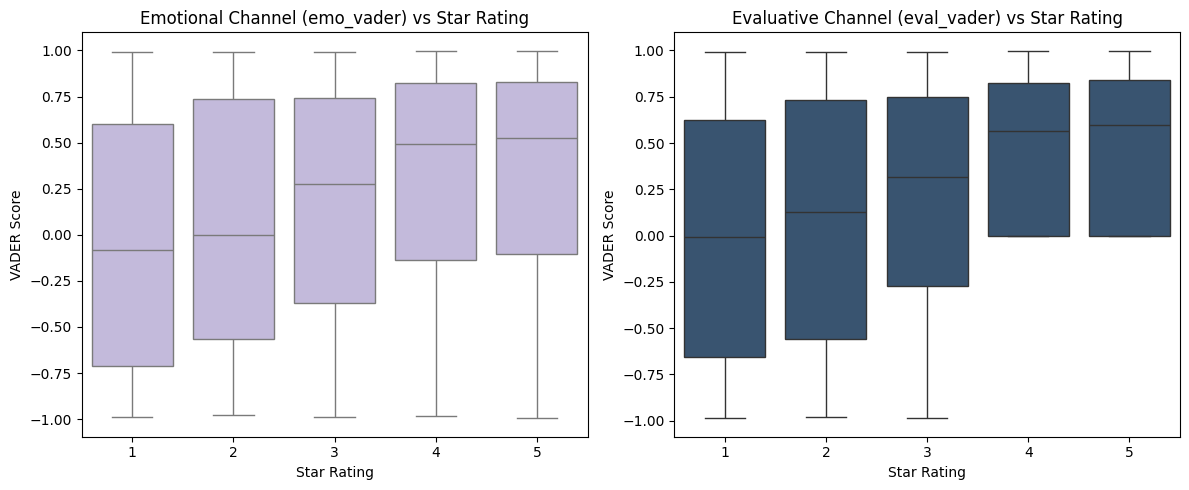

In [ ]:
# Boxplot: both channels vs star rating
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x="rating", y="emo_vader", data=df, ax=axes[0], color="#c1b4e1")
axes[0].set_title("Emotional Channel (emo_vader) vs Star Rating")
axes[0].set_xlabel("Star Rating")
axes[0].set_ylabel("VADER Score")

sns.boxplot(x="rating", y="eval_vader", data=df, ax=axes[1], color="#305479")
axes[1].set_title("Evaluative Channel (eval_vader) vs Star Rating")
axes[1].set_xlabel("Star Rating")
axes[1].set_ylabel("VADER Score")

plt.tight_layout()
plt.savefig("../Outputs/Figures/vader_channels_by_rating.png", dpi=150)
plt.show()

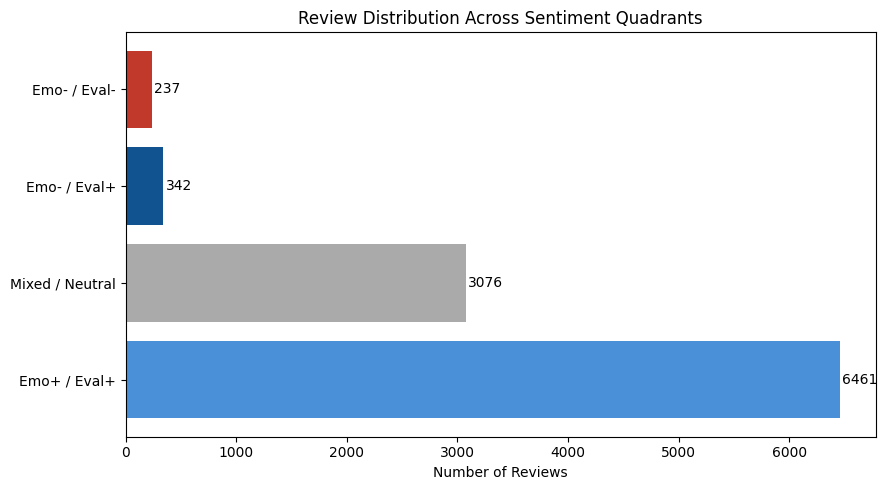

In [ ]:
# Quadrant distribution bar chart
bucket_counts = df["emo_eval_bucket"].value_counts()
colors = {
    "Emo- / Eval+": "#115391",
    "Emo+ / Eval+": "#4a90d9",
    "Mixed / Neutral": "#aaaaaa",
    "Emo+ / Eval-": "#e07b39",
    "Emo- / Eval-": "#c0392b"
}
bar_colors = [colors.get(b, "#aaaaaa") for b in bucket_counts.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(bucket_counts.index, bucket_counts.values, color=bar_colors)
ax.set_title("Review Distribution Across Sentiment Quadrants")
ax.set_xlabel("Number of Reviews")
for bar in bars:
    width = bar.get_width()
    ax.text(width + 20, bar.get_y() + bar.get_height() / 2,
            f"{int(width)}", va='center', fontsize=10)
plt.tight_layout()
plt.savefig("../Outputs/Figures/vader_quadrant_distribution.png", dpi=150)
plt.show()

## 7. Export

In [ ]:
df.to_csv("../Data/Processed/ushmm_tripadvisor_eng_vader.csv", index=False)
print(f"Saved {len(df)} rows to ../Data/Processed/ushmm_tripadvisor_eng_vader.csv")
print(f"New columns added: emo_vader, eval_vader, emo_eval_bucket")
print(f"\nQuadrant summary:")
print(df["emo_eval_bucket"].value_counts())

Saved 10116 rows to ../Data/Processed/ushmm_tripadvisor_eng_vader.csv
New columns added: emo_vader, eval_vader, emo_eval_bucket

Quadrant summary:
emo_eval_bucket
Emo+ / Eval+       6461
Mixed / Neutral    3076
Emo- / Eval+        342
Emo- / Eval-        237
Name: count, dtype: int64
